In [1]:
import pandas as pd
import numpy as np
import sys
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from typing import Dict, Optional, Tuple, Any, List
import math

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
synthetic_data_dictionary = {}
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df

            Datasets    pvalue              C-index                     HR
0             Origin  0.299257                0.531  1.192\n (0.856-1.660)
1       avatarsk5_42  0.809047                0.509  0.962\n (0.704-1.316)
2      avatarsk10_42  0.602012                0.509  0.920\n (0.672-1.260)
3           ctgan_42  0.106277                0.537  0.763\n (0.548-1.061)
4  gaussiancopula_42  0.285437                0.532  1.189\n (0.865-1.635)
5        synthpop_42  0.749410                0.502  0.947\n (0.686-1.309)
6            tvae_42       NaN  insufficient events    insufficient events


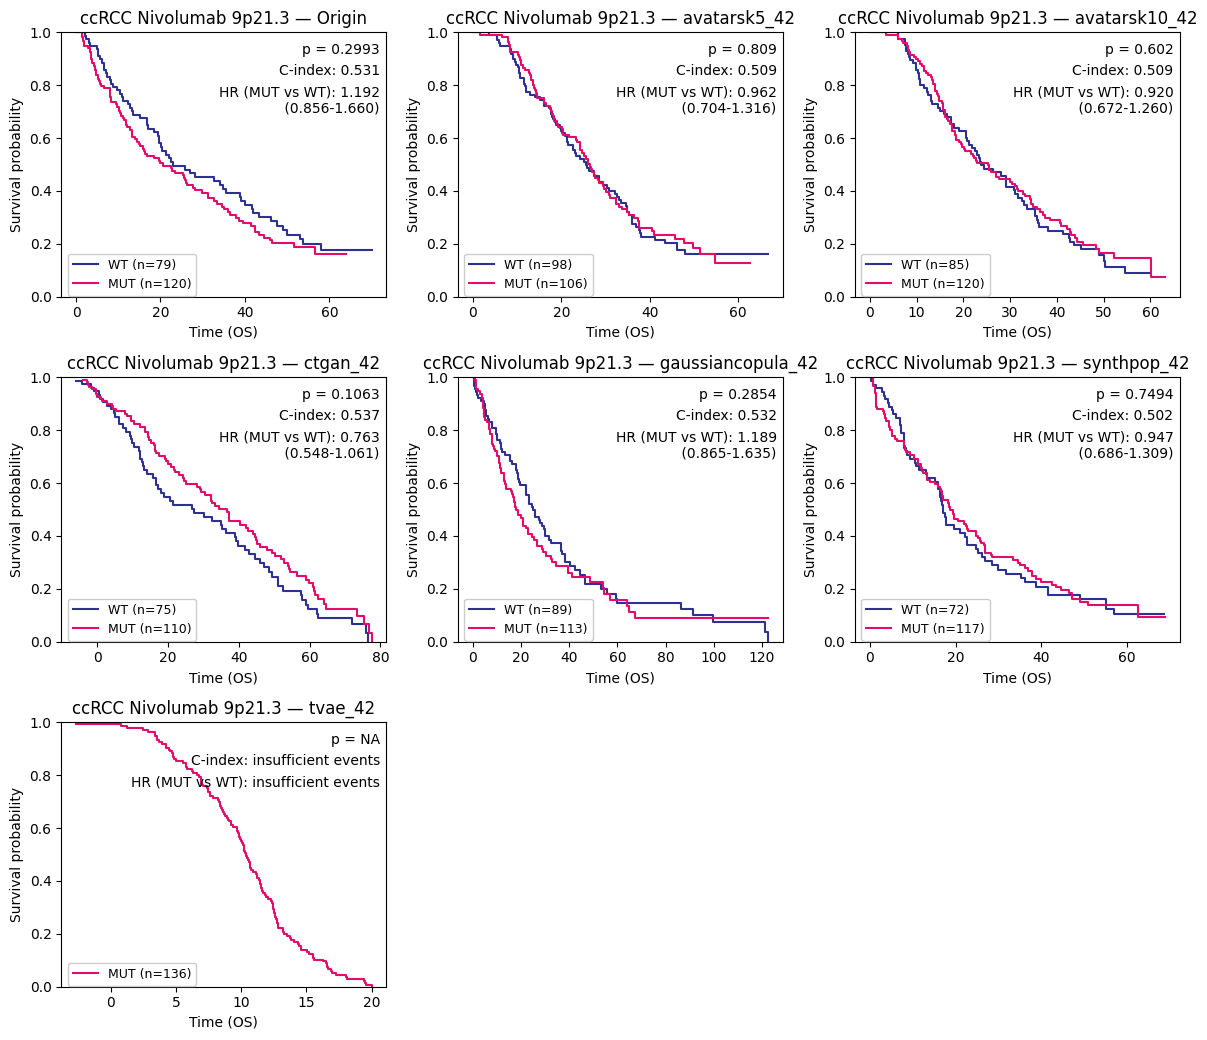

In [2]:
from SurvivalAnalysis import plot_survival_grid
import os

os.makedirs(f"SA_9p213/Seed_{seed}", exist_ok = True)

phenotype = {"Deletion_9p21.3": ["MUT", "WT"]}
# datasets_nivo = {}
# arm = "NIVOLUMAB"
# for k, df in dataset_dict.items():
#     nivo_df = df[df["Arm"]==arm]
#     nivo_df = nivo_df[nivo_df['Benefit']!='ICB']
#     datasets_nivo[k]=nivo_df
    
fig, summary = plot_survival_grid(
    dataset_dict,
    phenotype=phenotype,
    treatment=None,
    time_target="OS",
    event_target="OS_CNSR",
    ncols=3,
    figsize=None,
    show_censors=False,
    ci_show=False,
    title_prefix="ccRCC Nivolumab 9p21.3",
)

print(summary)
fig.savefig(f"SA_9p213/Seed_{seed}/KMCurve.png", dpi=300, bbox_inches="tight")
plt.show()
summary.to_csv(f'SA_9p213/Seed_{seed}/Summary.csv',index = False)

In [3]:
from SurvivalAnalysis import compute_similarity_scores

scored = compute_similarity_scores(summary, original_name="Origin")
pvalues = scored["pvalue_score"].values
cindex_scores = scored["C-index_score"].values
hr_scores = scored["HR_score"].values
avarages_scores = 1/3*(pvalues+cindex_scores+hr_scores)
scored["Average"] = avarages_scores
scored.to_csv(f'SA_9p213/Seed_{seed}/Scores.csv', index = False)